# Ship Hydrostatics — Demo

This notebook imports the `hydrostatics` module and computes the basic
hydrostatic properties of a hull from its table of offsets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hydrostatics import (
    waterplane_area,
    waterplane_coefficient,
    volume_of_displacement,
    block_coefficient,
)

## Input data — table of offsets

Half-breadths (m) and immersed sectional areas (m^2) at 7 equally spaced
stations, plus the main dimensions of the hull.

In [2]:
spacing = 5  # distance between stations (m)

half_breadths   = np.array([0.2, 1.8, 3.1, 3.6, 3.2, 2.0, 0.4])  # m
sectional_areas = np.array([1, 12, 20, 23, 19, 10, 2])           # m^2

length = 30   # length on the waterline (m)
beam   = 7.2  # maximum beam (m)
draft  = 3    # draft (m)

## Waterplane area and coefficient

$$A_w = 2 \cdot \frac{h}{3}\left(y_0 + 4y_1 + 2y_2 + \cdots + y_n\right)
\qquad C_w = \frac{A_w}{L \cdot B}$$

In [3]:
A_w = waterplane_area(half_breadths, spacing)
C_w = waterplane_coefficient(A_w, length, beam)

print(f"Waterplane area   Aw = {A_w:.2f} m^2")
print(f"Waterplane coeff  Cw = {C_w:.3f}")

Waterplane area   Aw = 142.67 m^2
Waterplane coeff  Cw = 0.660


## Volume of displacement and block coefficient

$$\nabla = \frac{h}{3}\left(A_0 + 4A_1 + 2A_2 + \cdots + A_n\right)
\qquad C_b = \frac{\nabla}{L \cdot B \cdot T}$$

In [4]:
volume = volume_of_displacement(sectional_areas, spacing)
C_b = block_coefficient(volume, length, beam, draft)

print(f"Volume of displacement  V  = {volume:.2f} m^3")
print(f"Block coefficient       Cb = {C_b:.3f}")

Volume of displacement  V  = 435.00 m^3
Block coefficient       Cb = 0.671


## Waterplane outline

The half-breadths mirrored about the centerline give the shape of the
waterplane along the length of the hull.

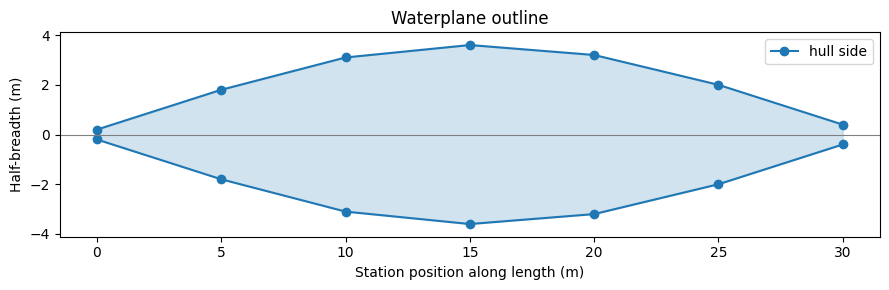

In [5]:
stations = np.arange(len(half_breadths)) * spacing

plt.figure(figsize=(9, 3))
plt.plot(stations, half_breadths, "o-", color="C0", label="hull side")
plt.plot(stations, -half_breadths, "o-", color="C0")
plt.fill_between(stations, half_breadths, -half_breadths, alpha=0.2, color="C0")
plt.axhline(0, color="gray", lw=0.8)
plt.xlabel("Station position along length (m)")
plt.ylabel("Half-breadth (m)")
plt.title("Waterplane outline")
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.show()